## Module 2 – Data Handling & Preprocessing_house_ML model_Linear_regressions

**Exploratory Data Analysis (EDA)** involves key steps like understanding the problem and data, data collection, data cleaning, descriptive statistics, data visualization, handling missing values and outliers, feature engineering, exploring variable relationships, and finally communicating insights.

These steps are iterative, helping to uncover patterns, identify anomalies, and form hypotheses for building better models and making informed decisions.  


  ---

  ## 🔹 EDA Steps for Machine Learning

  ### 1. **Understand the Problem & Dataset**

  * Identify **business objective** or ML task (classification, regression, clustering, etc.)
  * Define the Goal: Clarify the business goal or research question the data analysis aims to address.
  *Understand Variables: Identify the meaning of each variable, their data types (numerical, categorical), and any known data quality issues or constraints.

  * Load dataset (`pandas.read_csv`, SQL, etc.)
  * Check dataset shape (`df.shape`)
  * Display first few rows (`df.head()`)

  ---

  ### 2. **Data Collection**
  Gather all relevant raw data from appropriate sources, such as databases, CSV files, or APIs.
  ---

  ### 3. **Data Preparation and Cleaning**
  - Data Wrangling: Clean and organize the raw data into a format suitable for analysis.
  - Handle Missing Values: Identify and decide how to handle missing or null values, which can be by removal, imputation with the mean or median, or other methods depending on the data's distribution.
  - Handle Duplicates and Irregularities: Remove redundant data and address irregularities that can cause noise in the analysis.

  ### 3.1. **Data Types & Structure**

  * Inspect column types (`df.info()`)
  * Separate features into:

    * Numerical (continuous/discrete)
    * Categorical
    * Date/Time
    * Text/Unstructured
  * Identify target variable.

  ---

  ### 3.2 **Data Quality Check**

  * Missing values (`df.isnull().sum()`)
  * Duplicate records (`df.duplicated().sum()`)
  * Outliers detection (boxplots, IQR method, z-score)
  * Data entry errors (e.g., age = -5, salary = 9999999)

  ---
  ### 4. **Descriptive Statistics and Visualization**
  * Summary Statistics: Calculate descriptive statistics like mean, median, standard deviation, and frequency distributions to get a quick understanding of the dataset's central tendency and variability.
  * Visualize Distributions: Use histograms, box plots, and density plots to visualize the distribution of individual variables.
  ---

  ### 5. **Examine Relationships and Outliers**
  * Bivariate and Multivariate Analysis: Explore pairwise relationships between variables using scatter plots or more complex multivariate methods like heatmaps to identify patterns and correlations.
  * Outlier Detection: Identify and analyze outliers, which can skew results, and decide whether to remove or retain them based on the context.

  ### 5.1 **Univariate Analysis (Single Variable)**

  * Numerical features → Histogram, KDE, Boxplot, Summary stats (`df.describe()`)
  * Categorical features → Value counts, Bar plot, Pie chart

  ---

  ### 5.2 **Bivariate Analysis (Feature vs Target)**

  * Numerical vs Target:

    * Correlation (`df.corr()` + heatmap)
    * Scatter plots, boxplots
  * Categorical vs Target:

    * Grouped bar chart
    * Countplot with hue
    * Chi-square test (for independence)

  ---

  ### 5.3. **Multivariate Analysis**

  * Correlation matrix for numerical features
  * Pairplot/heatmap
  * Cross-tabulations
  * PCA/Dimensionality reduction (optional for visualization)

  ---
  ### 6. **Feature Engineering**
  Create new features or transform existing ones to better represent the underlying information and improve model performance.

  ---
  ### 6.1 **Feature Relationships**

  * Check multicollinearity (VIF score)
  * Identify strong predictors
  * Detect redundant features

  ---

  ### 6.2 **Feature Engineering Needs**

  * Encoding categorical variables (OneHot, Label Encoding)
  * Feature scaling (Normalization, Standardization)
  * Date/time feature extraction (day, month, weekday, etc.)
  * Domain-specific feature creation

  ---

  ### 6.3 **Class Imbalance Check (For Classification)**

  * Value counts of target variable
  * If imbalance exists → consider SMOTE, undersampling/oversampling, class weights

  ---
  ### 7. **Communicate Findings**
  Present the insights and discoveries from the EDA process to stakeholders.

  ---
  ### 8. **Iterate**
  EDA is an iterative process. You may need to revisit earlier steps to test new hypotheses, address emerging challenges, and refine your understanding of the data to build more robust models

  ### 10. **Key Insights & Hypothesis**

  * Summarize main findings
  * Identify which features are important
  * Document anomalies or patterns

  ---

  ✅ **Outcome of EDA** → Clean dataset + feature insights → Ready for preprocessing & model building.

  ---

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# - 1. DATA LOAD
# - 2. DATA INFO
# - 3. DATA CLEANING
#   - a. info
#   - b. remove unwanted columns
#   - c. duplicate
#   - d. null check
#   - e. clean null values (imputation of missing value )
#   - f. save the clean data

# - 4. DATA PREPROCESSING
    # - a. segregate categorical and numerical columns
    # - b. check the data pattern using graphs and show distributions
    # - c. data interpolation >> is a process of estimating data in a range, getting unknown values from known values
    # - d. data Feature Scalling
    # - e. To check outliers >> distplot, boxplot
    # - f. data encoding
    # - g. class imbalance >> one class has higeher percentage upsampling, downsampling, smote
    # - h. Assumptions of Machine Learning for Linear Regression
# - MACHINE LEARNING MODELING

In [ ]:
# data read
import pandas as pd
path =r'https://media.githubusercontent.com/media/shahil04/ds_materials/refs/heads/main/8.0_Machine%20Learning/class/Module%202%20Bengaluru_House_Data.csv'
df = pd.read_csv(path,encoding="utf-8")
df.head()

#### Hidden Data

<!--
### Handling Missing Values

#drop all the rows
df.dropna()
#drop a column with missing value
df.dropna(axis=1)
#imputation of missing value with mean

df['B'].fillna(df['B'].mean())
df['B'].fillna(df['B'].median())

df.drop('deck', axis = 1, inplace=True)
#homework>> create a separate column with flag 1 and 0

df["flag"]=df.age.apply(lambda x: 1 if pd.isna(x) else 0)


# Feature Scalling
std_data = []
for i in list(df['total_bill']):
    zscore = (i-mean)/std
    std_data.append(zscore)


#scaling is optional because it doesnt change the distribution of data
#before scaling
sns.distplot(df['total_bill'])

#after scaling
sns.distplot(std_data)

from sklearn.preprocessing import StandardScaler
#Normalization/minmax scaling
from sklearn.preprocessing import MinMaxScaler

#unit vector
from sklearn.preprocessing import normalize
#robust scaling >> you have outliers the data
#X-median/IQR
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()


#data interpolation >>  is a process of estimating data in a range, getting unknown values from known values
1. Linear Interpolation
2. cubic interpolation
3. Polynomial interpolation

#linear interpolation

x_new = np.linspace(1, 5, 10)
x_new
y_interp = np.interp(x_new, x, y)
y_interp

#cubic interpolation

x = np.array([1, 2, 3, 4, 5])
y = np.array([1, 8, 27, 64, 125])
plt.scatter(x, y)

from scipy.interpolate import interp1d

f = interp1d(x, y, kind = 'cubic')

x_new = np.linspace(1, 5, 10)
y_interp = f(x_new)


#polynomial interpolation

x = np.array([1, 2, 3, 4, 5])
y = np.array([1, 4, 9, 1, 25])

p = np.polyfit(x, y, 2)

x_new = np.linspace(1, 5, 10)
y_interp = np.polyval(p, x_new)
plt.scatter(x_new, y_interp)

===========================================
=======================================

#data encoding >> converting categorical column to numeric
#Nominal/OHE
#label and ordinal encoding
#target guided ordinal encoding

#nominal ohe >> binary vectors for each category
#single married, in a relationship
#single > [1, 0,a 0]
#married > [0, 1, 0]
#separated > [0, 0, 1]

import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

df = pd.DataFrame({"qualification": ["HS", "PG","GR", "HS", "PhD", "HS", "PG"]})
encoder = OrdinalEncoder(categories = [["HS", "GR", "PG", "PhD"]])
encoder.fit_transform(df[['qualification']])


#To check outliers >> distplot, boxplot
#dropping the outlier
#capping the outlier
#replace with mean and median
#Scaling and transformation

Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3-Q1
IQR

lower_fence = Q1-1.5*IQR
upper_fence = Q3+1.5*IQR

#dropping the outlier
df_filtered = df[(df.Salary >= lower_fence) & (df.Salary <= upper_fence)]

#replace the outliers with mean and median
df['Salary_mean_imputed'] = np.where((df.Salary >= upper_fence) | (df.Salary <= lower_fence), df['Salary'].mean(), df['Salary'])


#capping >> replacing outlier with the nearest values that is not outlier

lower_cap = df['Salary'].quantile(0.05) #lower cap as 5th percentile
upper_cap = df['Salary'].quantile(0.95)

df['Salary_capped'] = np.where(df['Salary'] < lower_cap, lower_cap,
                              np.where(df['Salary'] > upper_cap, upper_cap, df['Salary']))




#class imbalance >> one class has higeher percentage
#upsampling, downsampling, smote


import numpy as np
import pandas as pd
np.random.seed(1) #for reproducibility

no_samples = 1000
class_0_ratio = 0.9
no_class_0 = int(no_samples * class_0_ratio)
no_class_1 = 100

class_0 = {'feature1': np.random.normal(0, 1, no_class_0),
'feature2': np.random.normal(0, 1, no_class_0),
'target': [0]*no_class_0}


class_0 = pd.DataFrame(class_0)

class_1 = pd.DataFrame({'feature1': np.random.normal(3, 1, no_class_1),
'feature2': np.random.normal(3, 1, no_class_1),
'target': [1]*no_class_1})

df = pd.concat([class_0, class_1]).reset_index(drop = True)

df.target.value_counts(normalize = True)   # show in percentage use normalize true

df_minority = df[df.target == 1]
df_majority = df[df.target == 0]

#oversampling>>upsampling >>increasing the minority to majority no
from sklearn.utils import resample

df_minority_upsampled = resample(df_minority, replace=True, n_samples = len(df_majority), random_state =1)

#downsmapling
df_majority_downsampled = resample(df_majority, replace=False, n_samples = len(df_minority), random_state =1)


#SMOTE>> synthetic minority oversampling technique

from sklearn.datasets import make_classification

X, y = make_classification(n_samples = 1000, n_redundant = 0, n_features=2, n_clusters_per_class = 1, weights = [0.90], random_state = 1)

import matplotlib.pyplot as plt
plt.scatter(df_final['f1'], df_final['f2'], c = df_final['target'])


# !pip install imblearn
from imblearn.over_sampling import SMOTE

oversample = SMOTE()
X, y = oversample.fit_resample(df_final[['f1', 'f2']], df_final['target'])

df1 = pd.DataFrame(X, columns = ['f1', 'f2'])
df2 = pd.DataFrame(y, columns = ['target'])
oversample = pd.concat([df1, df2], axis = 1)

import matplotlib.pyplot as plt
plt.scatter(oversample['f1'], oversample['f2'], c = oversample['target'])

===========================================================
================================================================
===============================================================


 -->

# 🔹 EDA Steps for Machine Learning

### 1. **Data Load**

* Import libraries
* Load dataset (CSV, SQL, API, etc.)
* Preview dataset (`head`, `shape`)
---

✅ This outline now has both:

* Your **step-by-step workflow (load → clean → preprocess → model assumptions)**
* The **structured EDA stages (univariate, bivariate, multivariate, feature engineering, communication)**


## 1. Data Loading and Preprocessing.

In these steps, we will load the Bengaluru House Data dataset using pandas and perform an initial exploration to understand its structure and contents.

- **Data Import:** The dataset is loaded into a pandas DataFrame named `data`.
- **Shape:** The dataset contains 12,530 rows and 7 columns after initial cleaning.
- **Columns:**  
    - `location`: Area or locality of the property  
    - `size`: Number of bedrooms (e.g., "2 BHK", "4 Bedroom")  
    - `total_sqft`: Total area in square feet  
    - `bath`: Number of bathrooms  
    - `price`: Price of the property (in lakhs)  
    - `bhk`: Extracted number of bedrooms as integer  
    - `price_per_sqft`: Price per square foot

We will also check for missing values, data types, and unique values in key columns to guide further cleaning and preprocessing steps. This foundational understanding helps in identifying potential issues such as outliers, inconsistent data, and the need for encoding categorical variables.

---

### 2. **Data Info**

* Check dataset structure (`info`)
* Identify column data types (numerical, categorical, datetime, text)
* Identify target variable

In [ ]:
df.info()
# basic info about the data --> columns names, null values, datatypes ,sizes

In [ ]:
df.shape
# show the numbers of rows and cols

In [ ]:
df.ndim  # check the dimensions

In [ ]:
df.size # total values in data

### 3. **Data Cleaning**

* Inspect dataset info again
* Remove unwanted/irrelevant columns
* Handle duplicates
* Null value check
* Handle missing values (drop, mean/median/mode imputation, domain-specific methods)
* Save cleaned dataset

In [ ]:
df.head()

#### check unique values in Each columns

In [ ]:
# check columns names
df.columns

In [ ]:
df['area_type'] # show the single columns using column name

In [ ]:
type(df['area_type']) # check the datatype 

In [ ]:
df['area_type'].unique() # unique show the unique value in a specific column

In [ ]:
df['area_type'].nunique()  # nunique show the count of unique value in a specific column

In [ ]:
print(df['area_type'].nunique())

In [ ]:
# check the unique values in a column
print(df['area_type'].unique())

In [ ]:
df.columns

In [ ]:
for i in df.columns:
    print(i)
    # print(df[i].nunique())

In [ ]:
for col in df.columns:
    print(f'{col}: {df[col].nunique()}')

## 2.Check the null values

In [ ]:
# check null values
df.isnull()

In [ ]:
# check null values
df.isnull().sum()

# 2.1remove or replace the NUll values

In [ ]:
# 2.1.1 remove the columns
# In society  5502 null values (41%)
df.drop("society",axis=1)

In [ ]:
df

In [ ]:
# using reassign after dropping columns --> like inplace=True

# df = df.drop('society',axis=1)

# drop --> inrelevent columns
df.drop( 'society', axis=1 ,inplace=True) # inplace use for permanent delete the column from variable
# axis=1 means columns
# axis=0 means rows 

In [ ]:
df

## 2.2 Replace NUll Values/Replace

In [ ]:
df

In [ ]:
df.isnull().sum()

In [ ]:
df.head()

#### location null value replace

In [ ]:
# replace the value
# locations
df["location"].mode()

In [ ]:
df["location"].mode()[0]

In [ ]:
df["location"].value_counts()

In [ ]:
# replace the value
# locations
df["location"].mode()[0]

In [ ]:
df['location'].fillna('Whitefield')

In [ ]:
# df['location'].fillna('Whitefield')

df['location'].fillna(df["location"].mode()[0])

In [ ]:
# for permanent replace the null vaule use reassign

# df["location"].fillna(df["location"].mode()[0],inplace=True)

df['location'] = df['location'].fillna(df["location"].mode()[0])

In [ ]:
df.isnull().sum()

#### size null value replace

In [ ]:
# replace the size with mode
df["size"].mode()[0]

In [ ]:
df["size"].fillna(df["size"].mode()[0],inplace=True)

In [ ]:
df.isnull().sum()

2nd way of clean the size column data 

In [ ]:
int(df['size'][0].split(" ")[0])

In [ ]:
for i in df['size']:
    print(i)
    print(int(i.split(" ")[0]))

In [ ]:
df.isnull().sum()

In [ ]:
df.head()

#### bath null value replace

In [ ]:
df["bath"].mean()

In [ ]:
int(df["bath"].mean())

In [ ]:
df["bath"].fillna(int(df["bath"].mean()))

In [ ]:
df["bath"] = df["bath"].fillna(int(df["bath"].mean()))

In [ ]:
df.isnull().sum()

#### balcony null value replace

In [ ]:
df["balcony"] = df["balcony"].fillna(int(df["balcony"].mean()))

In [ ]:
df.isnull().sum()

In [ ]:
df.head()

### 3.Check DataTypes and correct with cleaning

In [ ]:
# change the datatypes of size(int), sqft(float),bath(int),balcony(int)
df.head()

In [ ]:
df.dtypes #

#### change the datatype of size column

In [ ]:
df['size']

In [ ]:
df["size"][0]

In [ ]:
df["size"][0].split()[0]

In [ ]:
int(df["size"][0].split()[0])

In [ ]:
# 2nd way to do 
df['size'].str.split()[0]

In [ ]:
# size datatype change object into int
int(df["size"][0].split(" ")[0])

In [ ]:
# # size columns cleaning
# df["size"].str.split(" ")[0][0]

In [ ]:
# create a fuctions for remove the text from size columns
def clean_size(x):
    return int(x.split(" ")[0])

In [ ]:
clean_size('3 bedroom')

In [ ]:
df["size"] = df['size'].apply(clean_size) 
# it use to apply any logic into a column

In [ ]:
df.dtypes

In [ ]:
# create a function to handle the error if value already in int or float
def clean_size(x):
  try:
    return int(x.split(" ")[0])
  except:
    return int(float(x))
# if column has null value then use float concept

In [ ]:
clean_size("2.5")

In [ ]:
df["size"].apply(clean_size)

In [ ]:
df.head(1)

In [ ]:
# change the column name
df = df.rename(columns={'size': 'size_bhk'})

In [ ]:
df.dtypes

### change the datatype of total_sqft

In [ ]:
# change the datatype using astype methods
df['total_sqft'].astype(float)

In [ ]:
# df.drop(columns=["size"],inplace=True)

In [ ]:
df["total_sqft"].unique()[:30]

In [ ]:
df["total_sqft"][30]

In [ ]:
d = df["total_sqft"][30].split("-")
d

In [ ]:
d[0].strip()

In [ ]:
float(d[0].strip())

In [ ]:
(float(d[0].strip()) + float(d[1].strip())) /2

In [ ]:
# it show the diffrent diffrent patterns in total_sqrt columns
for  i in df['total_sqft']:
    try:
        if type(float(i)) == float or ' - ' in i:
                pass
        if '-' in i:
           pass
    except ValueError:
        print(i)

In [ ]:
shown = set()

for i in df['total_sqft'].dropna():
    try:
        float(i)
        
    except ValueError:
        if '-' in i:
            continue   # skip range pattern
        
        pattern = i

        if pattern not in shown:
            # print(i)
            shown.add(pattern)
shown

In [ ]:
# Logic 1 to convert all unit into sqft unit
import re

def convert_to_sqft(value):
    value = str(value).strip()

    # Ignore ranges such as "1195 - 1440"
    if '-' in value:
        temp =value.split("-")
        return (float(temp[0]) + float(temp[1]))/2

    match = re.match(r'([\d.]+)\s*(.*)', value)

    if not match:
        return value

    number = float(match.group(1))
    unit = match.group(2).lower().strip()

    conversion = {
        'acres': 43560,
        'acre': 43560,
        'sq. meter': 10.7639,
        'sq. meters': 10.7639,
        'sq. yards': 9,
        'sq. yard': 9,
        'cents': 435.6,
        'cent': 435.6,
        'grounds': 2400,
        'ground': 2400,
        'guntha': 1089,
        'perch': 272.25
    }

    if unit in conversion:
        return number * conversion[unit]

    # Already a plain sqft number
    try:
        return float(value)
    except:
        return value


df['total_sqft'] = df['total_sqft'].apply(convert_to_sqft)

In [ ]:
# create a logic functions for convert the datatypes of total_sqrt columns
def convertRange(x):
    temp = x.split('-')
    if len(temp) == 2:
        return (float(temp[0]) + float(temp[1]))/2
    try:
        return float(x)
    except:
        return None

In [ ]:
convertRange('2100')

In [ ]:
# df["total_sqft"]=df["total_sqft"].apply(convertRange)

### 2nd way to create a full conversion logic


In [ ]:
df.isnull().sum()

In [ ]:
df.head(1)

In [ ]:
df.dtypes

In [ ]:
# astype -->change the data type
df["total_sqft"] = df["total_sqft"].astype('float')

In [ ]:
# astype -->change the data type
df["bath"] = df["bath"].astype('int')
# astype -->change the data type
df["balcony"] = df["balcony"].astype('int')

In [ ]:
df.dtypes

In [ ]:
df.isnull().sum()

In [ ]:
df.head()

#### Save the clean data into csv format

In [ ]:
df.to

In [ ]:
# save the clean file
df.to_csv("Cleaned_data.csv",index=False)
# df.to_csv("Cleaned_data.csv",index=False)

## Create a basic ML Model for Demo 

In [ ]:
import pandas as pd
df = pd.read_csv("Cleaned_data.csv")
df.head()

In [ ]:
## Model Building 
# 1. select the numerical columns
# 2. seprate the x and y
# 2.1 split the data into training testing
# 3. load the algorithms and create the object of algoritms(linear regression)
# 4. train the model --> find the pattern value from data
# 5. test then model/predict
# 6. Evaluate/accuracy the model

# 7. fine tuning the model(for improve accuracy)

In [ ]:
df.head()

In [ ]:
pd.DataFrame(df["total_sqft"])

In [ ]:
# define x(features) and y(target/label data)
x =pd.DataFrame(df["total_sqft"])
y =df["price"] 

In [ ]:
y

In [ ]:
x.shape

In [ ]:
# 2.1 split the data into training testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y,test_size=.20,random_state=45)

In [ ]:
print(x_train.shape)
print(x_test.shape)

In [ ]:
df.head()

In [ ]:
# 3. load the algorithms and create the object of algoritms
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [ ]:
# 4. train the model --> find the pattern value from data
lr.fit(x_train,y_train)

In [ ]:
# coffecient, intercept
print(lr.intercept_)
print(lr.coef_)

In [ ]:
# check the trainning accuracy
lr.score(x_train,y_train)

In [ ]:
# check the testing accuracy
lr.score(x_test,y_test)

In [ ]:

# 5. test then model/predict
y_pred = lr.predict(x_test)
y_pred

In [ ]:
y_test

In [ ]:
# 1000 --> price
sqrt = int(input("Enter total_sqft: "))

lr.predict([[sqrt]])

In [ ]:
# save the model
import pickle
pickle.dump(lr,open("lrmodel.pkl","wb"))

### add more columns data for training 

In [ ]:
df.head()

In [ ]:
df.columns

In [ ]:
x = df[['size_bhk', 'total_sqft','bath', 'balcony']]
y= df['price']

In [ ]:
# 2.1 split the data into training testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y,test_size=.20,random_state=45)

# 3. load the algorithms and create the object of algoritms
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# 4. train the model --> find the pattern value from data
lr.fit(x_train,y_train)

In [ ]:
# coffecient, intercept
print(lr.intercept_)
print(lr.coef_)
# check the testing accuracy
lr.score(x_test,y_test)

In [ ]:
# Example to predict the price using  [size_bhk,total_sqrt,bath,balcony] columns
model =lr
total_sqrt = int(input("Enter total_sqft: "))
bath = int(input("Enter number of bathrooms: "))
size_bhk = int(input("Enter number of bedrooms (BHK): "))
balcony = int(input("Enter number of balcony: "))

model.predict([[size_bhk,total_sqrt,bath,balcony]])

# x = df[['size_bhk', 'total_sqft','bath', 'balcony']]

In [ ]:
df.head() 

### 4. **Data Preprocessing**

-1. Perform EDA FOR DATA DISTRIBUTIONS Check
* basic Statistical summary 
* Segregate categorical & numerical columns
* Explore data distribution (graphs, histograms, boxplots, distplots)

* Data interpolation (estimate unknown values from known values) already done in data cleaning
* Handle class imbalance (Upsampling, Downsampling, SMOTE, Class weights)
* Feature scaling (Normalization, Standardization) --> change the range/or fix the 
* Outlier detection & treatment (boxplot, z-score, IQR method)
* Data encoding (Label Encoding, OneHot Encoding)

* find the correlations bw variables
* Check assumptions of ML models (e.g., Linear Regression – linearity, normality, multicollinearity, homoscedasticity)


In [ ]:
import pandas as pd
df = pd.read_csv("Cleaned_data.csv")
df.head()

## Perform EDA for analysis data or understand the data nature

Exploratory Data Analysis (EDA) is a crucial process used by data scientists to analyze and summarize datasets through statistical measures and visualizations before building predictive models. It helps spot patterns, detect anomalies, check assumptions, and find hidden relationships.

### 5. **Descriptive Statistics & Visualization**

* Summary statistics (`describe`)
* Numerical feature distribution (histogram, KDE, boxplot)
* Categorical feature distribution (countplot, bar chart, pie chart)


In [ ]:
# describe use for Summarize statistics for numerical features
print("Descriptive Statistics for Numerical Features:")
df.describe()

In [ ]:
df.describe(include="O")
# for oject datatype columns    

In [ ]:
df.describe(include="all")
# both numerical and categorical

#### CHECK numerical columns and categorical Columns

In [ ]:
df.dtypes

In [39]:
df.columns
# show the ALL columns name as list

Index(['area_type', 'availability', 'location', 'size_bhk', 'total_sqft',
       'bath', 'balcony', 'price'],
      dtype='object')

In [ ]:

for i in df.columns:
  if df[i].dtype != 'object':
    print(i)

area_type
availability
location


In [42]:
numerical_cols =[]
catgorical_cols =[]

for i in df.columns:
    if df[i].dtype == 'object':
        # print(i)
        catgorical_cols.append(i)
    else:
        numerical_cols.append(i) 

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", catgorical_cols)

Numerical Columns: ['size_bhk', 'total_sqft', 'bath', 'balcony', 'price']
Categorical Columns: ['area_type', 'availability', 'location']


In [ ]:
import matplotlib.pyplot as plt
d = [3,4,2,3,1,2,3,4,5,6,5,2,2]
plt.hist(d, bins=10)
plt.show()

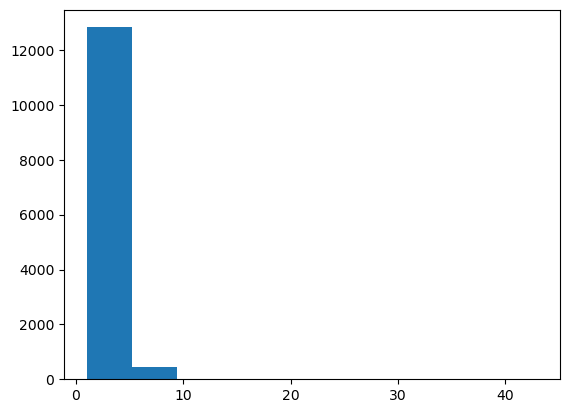

In [47]:
# pip install matplotlib seaborn
import matplotlib.pyplot as plt
plt.hist(df['size_bhk'])
plt.show()

In [49]:
df['size_bhk'].value_counts()

size_bhk
2     5544
3     4857
4     1417
1      656
5      356
6      221
7      100
8       89
9       54
10      14
11       4
27       1
19       1
16       1
43       1
14       1
12       1
13       1
18       1
Name: count, dtype: int64


Visualizing Distributions of Numerical Features:


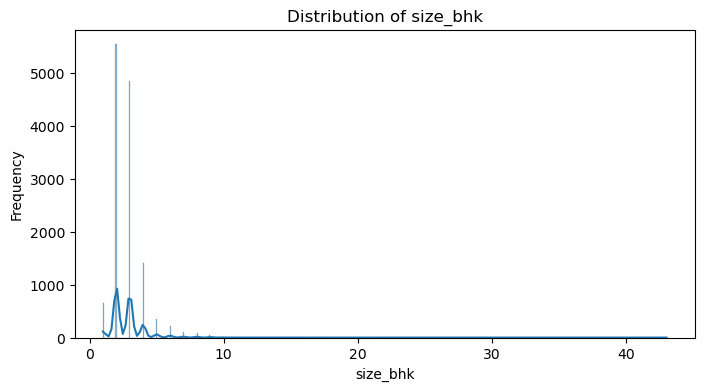

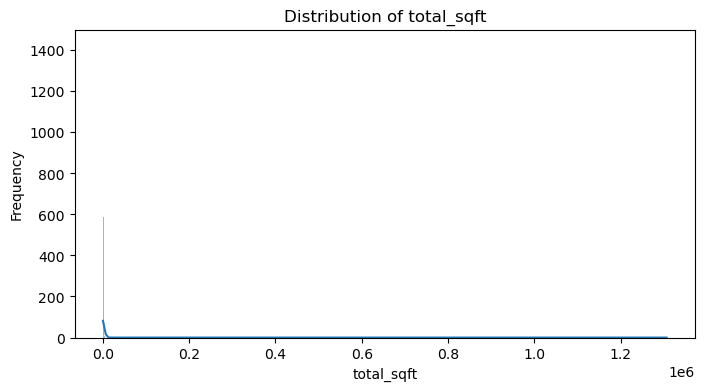

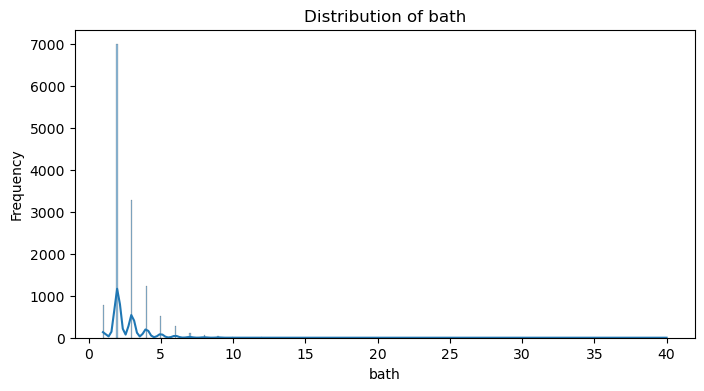

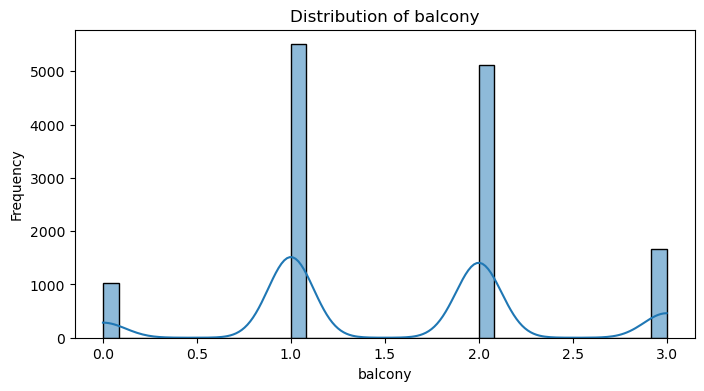

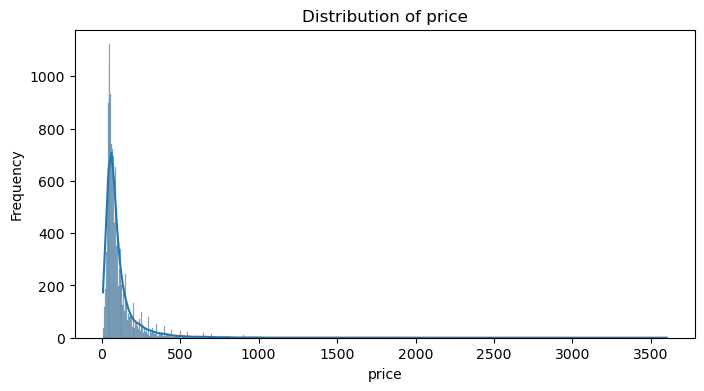

In [50]:
# Visualize distributions of numerical features
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
numerical_cols = df.select_dtypes(include=np.number).columns
print("\nVisualizing Distributions of Numerical Features:")
for col in numerical_cols:
    if col != 'price_boxcox': # Exclude the transformed price for now if you want to focus on original
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()


Visualizing Distributions of Categorical Features:


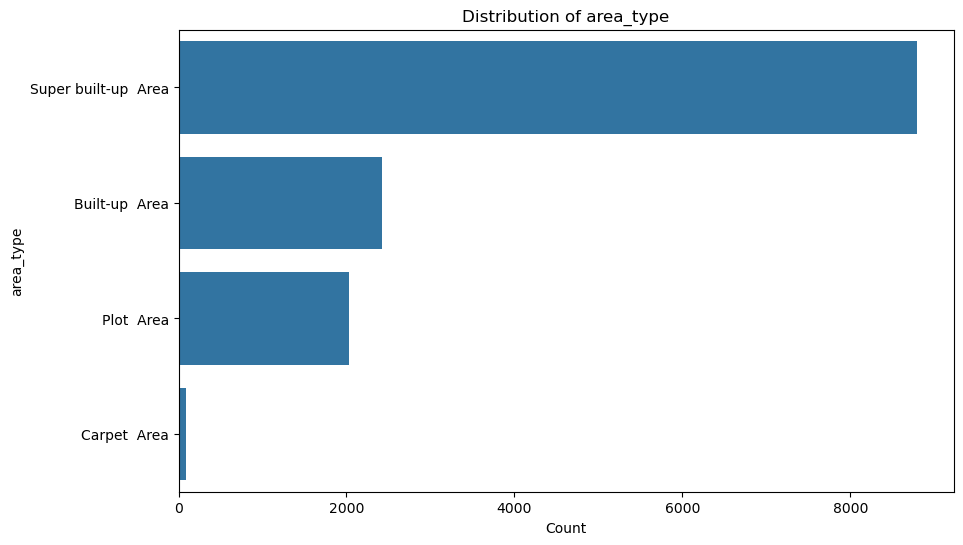

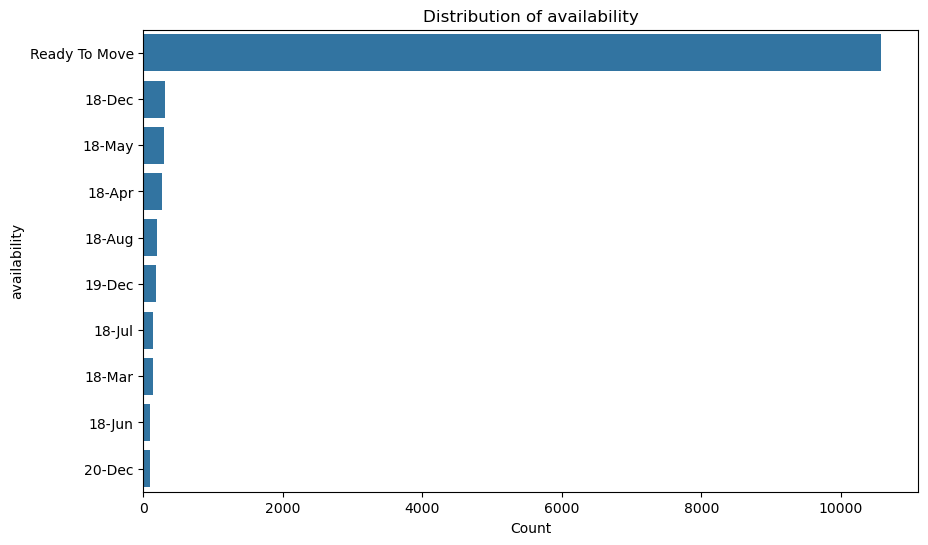

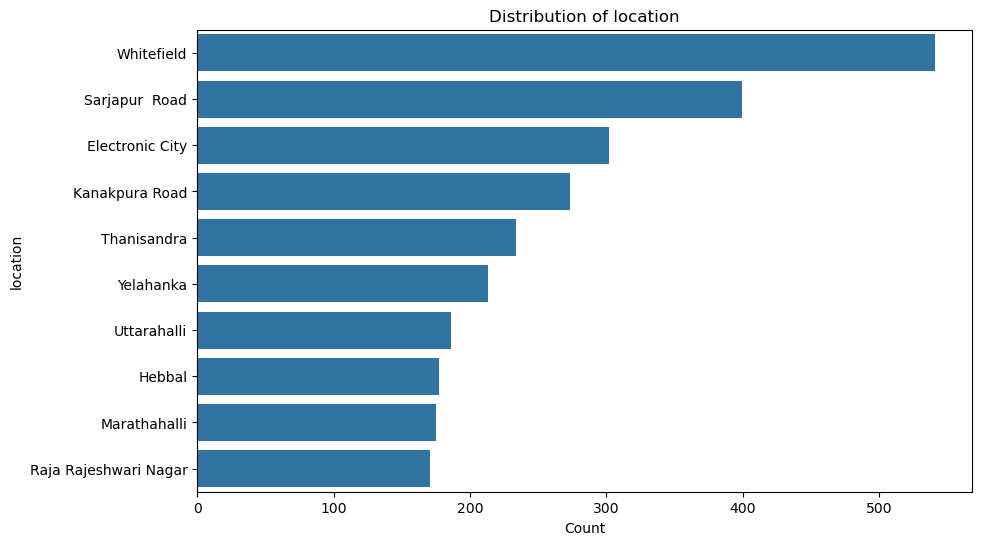

In [51]:
# Visualize distributions of categorical features
categorical_cols = df.select_dtypes(include='object').columns
print("\nVisualizing Distributions of Categorical Features:")
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index[:10]) # Display top 10 for readability
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

### 6. **Examine Relationships** 
Univariate Analysis,bi-variate, multi-variate,(optional) Correlations 

#### 6.1 **Univariate Analysis**

* Individual variable distributions


Visualizing Distributions of Numerical Features:


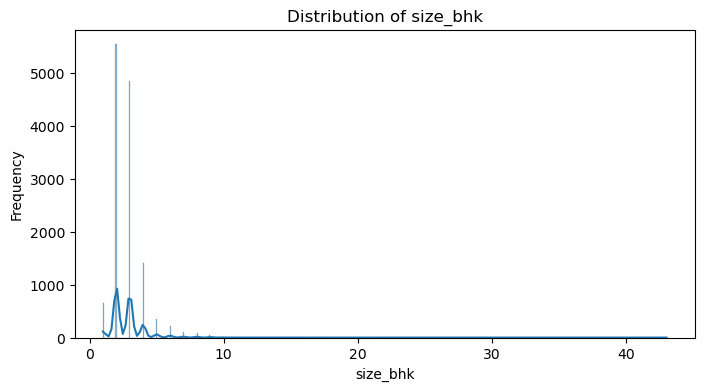

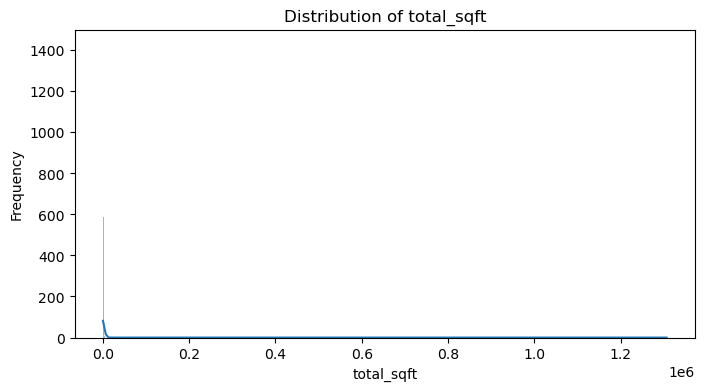

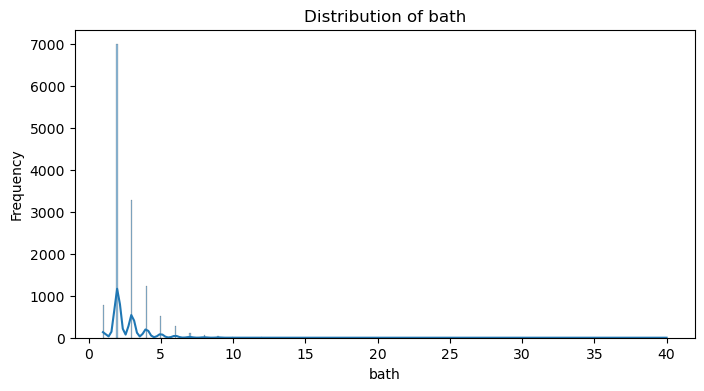

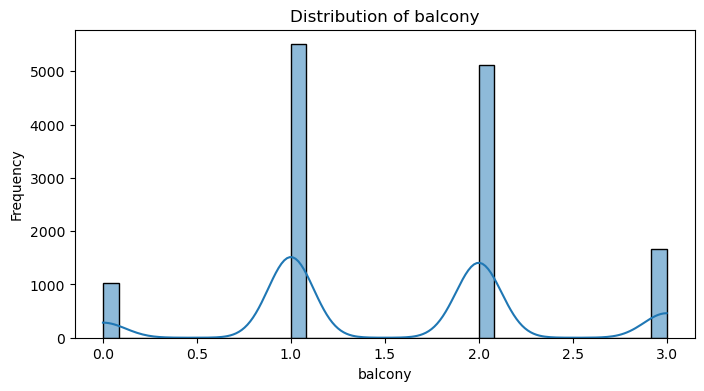

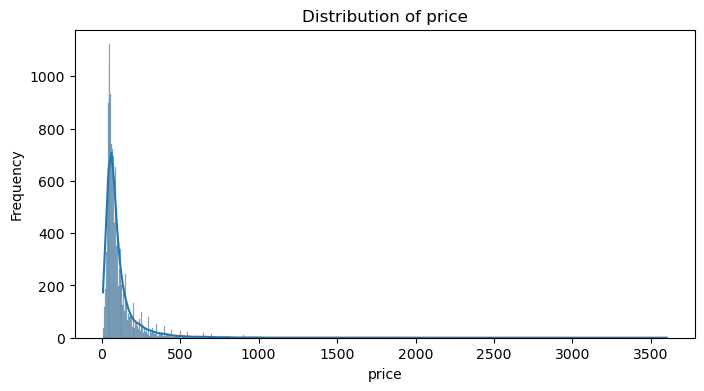


Visualizing Distributions of Categorical Features:


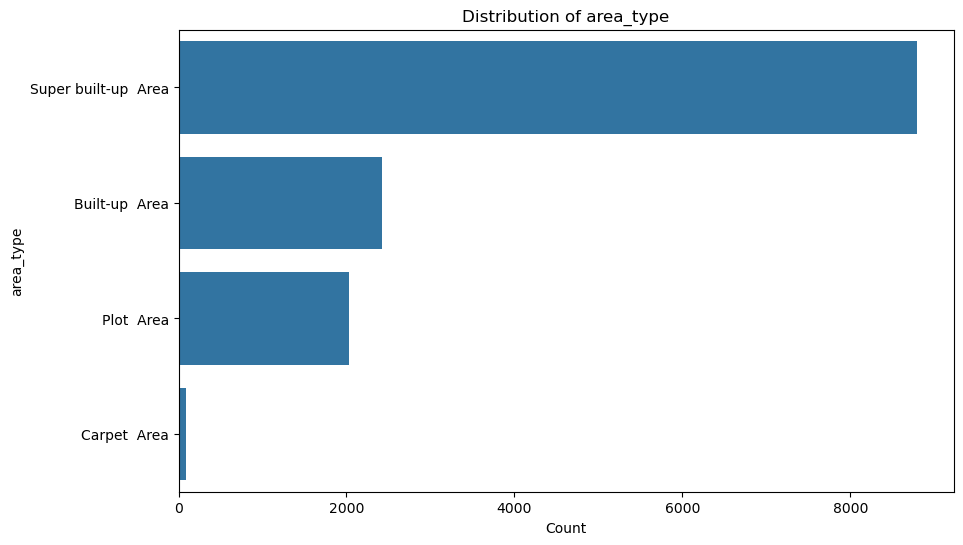

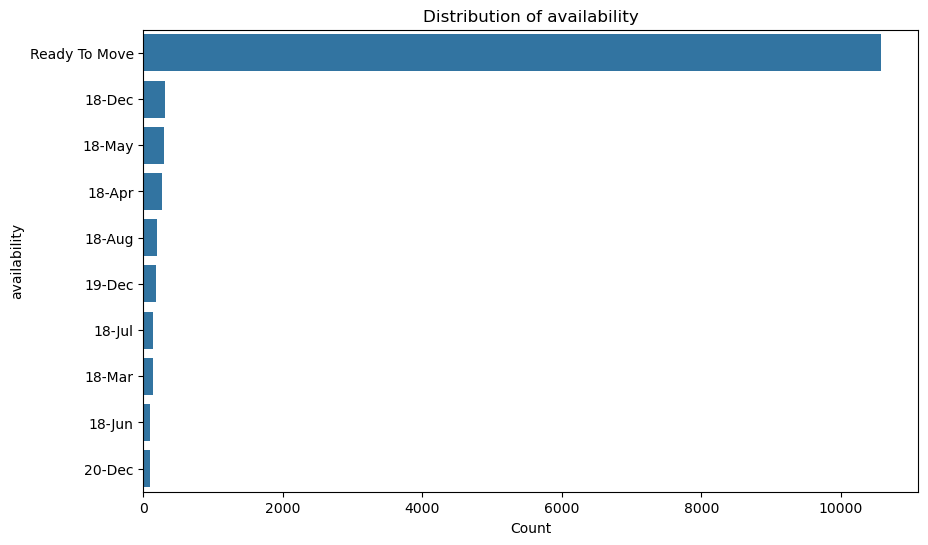

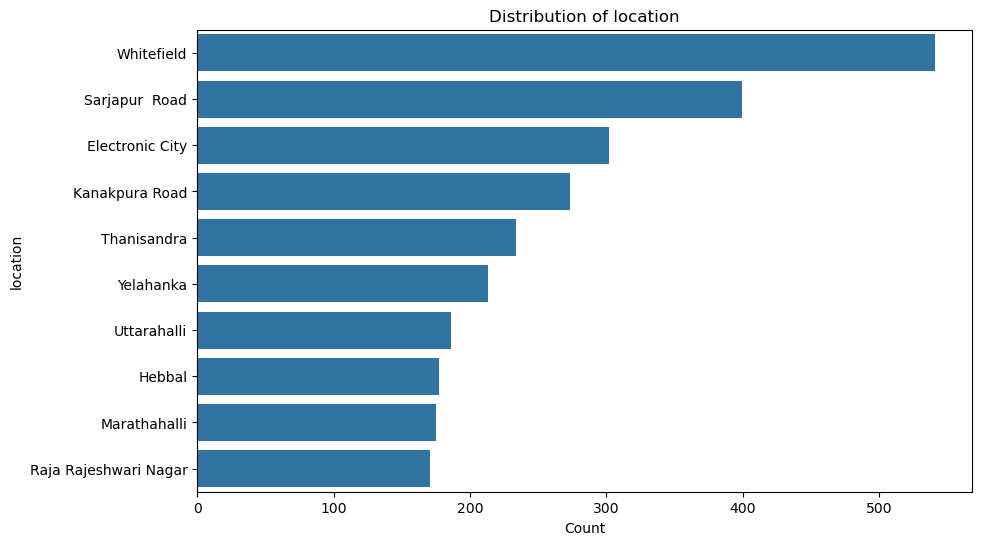

In [52]:
# Visualize distributions of numerical features
numerical_cols = df.select_dtypes(include=np.number).columns
print("\nVisualizing Distributions of Numerical Features:")
for col in numerical_cols:
    if col != 'price_boxcox': # Exclude the transformed price for now if you want to focus on original
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

# Visualize distributions of categorical features
categorical_cols = df.select_dtypes(include='object').columns
print("\nVisualizing Distributions of Categorical Features:")
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index[:10]) # Display top 10 for readability
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()




#### 6.2 **Bivariate Analysis**

* Numerical vs Target (correlation, scatterplot, boxplot)
* Categorical vs Target (grouped bar chart, countplot, chi-square test)

#### 6.3 **Multivariate Analysis**

* Correlation matrix & heatmap
* Pairplots
* PCA / dimensionality reduction (optional for visualization)


In [ ]:
# Bivariate Analysis (Numerical vs Target)
print("\nBivariate Analysis (Numerical vs Target):")
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'price' in numerical_cols:
    numerical_cols.remove('price') # Exclude target variable from features
    if 'price_boxcox' in numerical_cols:
        numerical_cols.remove('price_boxcox') # Exclude transformed target as well

    for col in numerical_cols:
        plt.figure(figsize=(8, 4))
        sns.scatterplot(data=df, x=col, y='price')
        plt.title(f'Scatter plot of {col} vs Price')
        plt.xlabel(col)
        plt.ylabel('Price')
        plt.show()

# Multivariate Analysis (Correlation Matrix and Heatmap)
print("\nMultivariate Analysis (Correlation Matrix):")
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### 7. **Feature Engineering**

* Create new features
* Extract date/time features (day, month, weekday, etc.)
* Domain-specific feature creation


In [ ]:
# Feature Engineering: Create 'price per square foot'
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']
display(df.head())

### 9. **Communicate Findings**

* Present visualizations & reports
* Share insights with stakeholders

### Summary of Key EDA Findings

Based on the Exploratory Data Analysis performed:

* **Data Overview:** We loaded and inspected the Bengaluru House Data, understanding its shape, columns, and initial data types.
* **Data Cleaning:**
    * Missing values were handled for `location`, `size`, `total_sqft`, `bath`, and `balcony` by imputation with the mode or mean.
    * Irrelevant columns (`availability`, `society`) were dropped.
    * Data types were corrected, specifically converting `size` to `bhk` (integer) and `total_sqft` to float, handling ranges.
    * Outliers were addressed in `total_sqft`, `bath`, `price`, and `bhk`.
* **Distribution Analysis:** Visualizations (histograms, countplots) provided insights into the distribution of individual features. We observed the distribution of numerical features and the counts of different categories in `area_type` and `location`.
* **Relationship Analysis:**
    * Scatter plots showed relationships between numerical features and `price`.
    * A correlation matrix highlighted the linear relationships between numerical variables. `total_sqft`, `bath`, and `bhk` show positive correlations with `price`.
* **Feature Engineering:** A new feature, `price_per_sqft`, was created, which can be a significant predictor of house prices.
* **Skewness Handling:** The `price` column's skewness was addressed using a Box-Cox transformation, resulting in a more normally distributed variable (`price_boxcox`).

These findings provide a solid foundation for the next steps in data preprocessing and machine learning model building.

### 10. **Iterate & Refine**

* Revisit earlier steps if needed
* Test new hypotheses


### 11. **Key Insights & Hypotheses**

* Summarize final findings
* Highlight important features
* Document anomalies & patterns


## Prepare the data for  machine Learning

In [ ]:
# EDA-Info,shape
# Data Cleaning (done)
# Handling Missing Values(done)
# Handling Outliers

# Handling Skewness

# Data Encoding

# Feature Scaling -Normalization and Standardization

# Feature Engineering

In [ ]:
# load the clean data
df = pd.read_csv("/content/Cleaned_data.csv")
df.head()

In [ ]:
# df.drop(columns=["Unnamed: 0"],inplace=True)

# Handling Outliers

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# check outliers
# df['total_sqft']
plt.boxplot(df['total_sqft'])
plt.show()

sns.boxenplot(df['total_sqft'])
plt.show()
sns.violinplot(df['total_sqft'])
plt.show()

In [ ]:
# Q. show the details of sales above 30k sqrtfeet
df[df["total_sqft"]>30000]

In [ ]:
df = df[df["total_sqft"]<30000]


In [ ]:
df[df["total_sqft"]>30000]

In [ ]:
# bath	balcony	price	bhk
l = ['bath',	'balcony',	'price',	'bhk']
for i in l:
  print(i)
  sns.boxenplot(df[i])
  plt.show()

In [ ]:
# bath 20,pric 3000, bhk 20 conditions for outliers
df = df[df["bath"]<20]
df = df[df["price"]<3000]
df = df[df["bhk"]<20]

# df[(df["bath"]>20) ! (df["price"]>30000) ! (df["bhk"]>20)]

In [ ]:
df.head()

In [ ]:
# check outliers for categorical values
df['area_type'].value_counts()

In [ ]:
df['location'].value_counts()

In [ ]:
(df['location'].value_counts().reset_index()["count"]==1).sum()

# Handling Skewness

Skewness is a statistical measure that describes the asymmetry of a probability distribution, indicating whether the data is stretched more toward the left or right of the mean



In [ ]:
# check the distributions
# histogram only for numerical columns -->specialy from continous data
for i in df.columns:
  if df[i].dtype != 'object':
    lab = i+" Skewness: "+str(df[i].skew())
    # print(lab)
    # print(df[i].skew())
    sns.histplot(df[i],kde=True)

    plt.legend([lab])
    plt.show()

In [ ]:
# skewness handle
df['price'].skew()

In [ ]:
np.sqrt(df['price']).skew()

In [ ]:
np.square(df['price']).skew()

In [ ]:
np.log(df['price']).skew()

In [ ]:
sns.histplot(np.log(df['price']),kde=True)

In [ ]:
# https://machinelearningmastery.com/skewness-be-gone-transformative-tricks-for-data-scientists/

In [ ]:
from scipy.stats import boxcox

# Apply Box-Cox transformation to the 'price' column
df['price_boxcox'], lambda_price = boxcox(df['price'])

# Display the skewness of the original and transformed price
print(f"Original Price Skewness: {df['price'].skew()}")
print(f"Box-Cox Transformed Price Skewness: {df['price_boxcox'].skew()}")

# Visualize the distribution of the transformed price
sns.histplot(df['price_boxcox'], kde=True)
plt.title('Distribution of Box-Cox Transformed Price')
plt.xlabel('Box-Cox Transformed Price')
plt.ylabel('Frequency')
plt.show()

# Feature Scaling -Normalization and Standardization

## Scaling
- change the range of value in fixed range
- Normalization (min-max scaler) -->range (0-1)/(-1 to 1)
- Standarization (z-score) --> mean=0, std=1

In [ ]:
# x-xmin/xmax-xmin
li = [1,2,3,4]
for x in li:
  new_x = (x-min(li))/(max(li)-min(li))

  print(new_x)

In [ ]:
# !pip install scikit-learn
# scaling
from sklearn.preprocessing import  MinMaxScaler,StandardScaler, RobustScaler

In [ ]:
df.head()

In [ ]:
# obj = classname()
# obj.methods(args)

In [ ]:
min_max = MinMaxScaler()
# change the range of total_sqft into 0 to 1
min_max.fit_transform(df[["total_sqft"]])

scaled_data = min_max.fit_transform(df[["total_sqft"]])
scaled_data

In [ ]:
# reassign
df["total_sqft"] = scaled_data
df.head()

In [ ]:
scaler = StandardScaler()
# change the range of where mean=0 and std =1
scaled_data = scaler.fit_transform(df[["total_sqft"]])
scaled_data

In [ ]:
# robust
scaler = RobustScaler()
# Why use robust scaling
# Handles outliers: It is robust to the presence of outliers, which can distort other scaling methods that rely on the mean and standard deviation.
# Less sensitive to skewed data: It is suitable for datasets with non-normal distributions, which are common in real-world data.
# Improves model performance:
# X_scaled=(X-X_median)/IQR)
scaled_data = scaler.fit_transform(df[["total_sqft"]])
scaled_data

In [ ]:
df

## Encoding

Encoding in machine learning is the process of converting categorical data(like text or non-numeric labels) into a numerical format that machine learning algorithms can understand and process

In [ ]:
df.head()

## encoding
* types
  1. nominal/Label encoding --> only name in data (ranking is not important)
  2. ordinal encodnig --> (ranking is important)
  3. one-hot encoding/ df_dummies -->( all are equal)
  

In [ ]:
df["area_type"].unique()

In [ ]:
df["area_type"].head(5)

In [ ]:
# sk-learn
# preprocessing

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder , OneHotEncoder

label= LabelEncoder()

l = label.fit_transform(df["area_type"])

print(l[:50])

In [ ]:
label.classes_

In [ ]:
df["area_type"].head()

In [ ]:
df["area_type"].unique()

In [ ]:
# Ordinal for apply the order in distinct values

ord = OrdinalEncoder(categories=[["Super built-up  Area","Built-up  Area","Plot  Area","Carpet  Area"]])

o = ord.fit_transform(df[["area_type"]])
print(o[:50])

# o = ord.fit_transform(df["area_type"].values.reshape(-1,1))

In [ ]:
ord.categories_

In [ ]:
# show the data with actual data
for i in zip(df["area_type"],o):
  print(i)

In [ ]:
# Binary number --> 0,1 if value then 1 and rest of then equal 0
ohe = OneHotEncoder()

o =ohe.fit_transform(df[["area_type"]]).toarray()

In [ ]:
o

In [ ]:
ohe.get_feature_names_out()

In [ ]:
area_ohe = pd.DataFrame(o,columns=ohe.get_feature_names_out())
area_ohe

In [ ]:
df.to_csv("data_preprocess_for_ml.csv",index=False)

In [ ]:
# add data into existing df and area_ohe into df1
df1 = pd.concat([df,area_ohe],axis=1,)
df1

In [ ]:
# same do with locations -->for OHE encoding
ohe = OneHotEncoder()

l =ohe.fit_transform(df[["location"]]).toarray()
l

In [ ]:
location = pd.DataFrame(l,columns=ohe.get_feature_names_out())
location

In [ ]:
df1 = pd.concat([df1,location],axis=1)  # also apend location ohe

In [ ]:
df1.drop(columns=["area_type","location"],inplace=True) # drop the string/object value columns

In [ ]:
df.head()

In [ ]:
df1.head()

In [ ]:
df

### **Feature Relationships**

* Check multicollinearity (VIF)
* Identify strong predictors
* Remove redundant features


In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Separate features (X) from the target variable (y)
# Exclude the original 'price' and the Box-Cox transformed 'price_boxcox' if they exist in df
numerical_cols_original = df.select_dtypes(include=np.number).columns.tolist()
if 'price' in numerical_cols_original:
    numerical_cols_original.remove('price')
if 'price_boxcox' in numerical_cols_original:
     numerical_cols_original.remove('price_boxcox') # Exclude transformed price

# Create a DataFrame with just the numerical features from the original df
numerical_features_df = df[numerical_cols_original]

# Handle potential infinite VIF if there's perfect multicollinearity (e.g., constant column)
# Add a small constant to avoid division by zero if a column has zero variance
numerical_features_df = numerical_features_df + 1e-9

# Calculate VIF for each numerical feature
vif_data = pd.DataFrame()
vif_data["feature"] = numerical_features_df.columns
# Ensure the data type is float for variance_inflation_factor
vif_data["VIF"] = [variance_inflation_factor(numerical_features_df.values.astype(float), i)
                   for i in range(numerical_features_df.shape[1])]

print("Variance Inflation Factor (VIF) for Numerical Features:")
display(vif_data.sort_values(by="VIF", ascending=False))


Variance Inflation Factor (VIF) for Numerical Features:


,feature,VIF
0,size_bhk,26.581525
2,bath,25.548511
3,balcony,3.266036
1,total_sqft,1.014941


In [ ]:
# Identify features with high VIF to remove
# Based on the calculated VIF values, both 'bath' (VIF: 26.96) and 'bhk' (VIF: 26.31) have high multicollinearity. This is likely because the number of bathrooms and the number of bedrooms are often strongly related to each other and possibly to the total square footage of the property.

# Having high multicollinearity between features can affect the interpretation and stability of some linear models. You might consider:

# Removing one of the highly correlated features: For example, you could remove either 'bath' or 'bhk'.
# Using techniques less sensitive to multicollinearity: Models like Ridge or Lasso regression include regularization that can handle multicollinearity.
# Combining features: Create a new feature that represents the relationship between 'bath' and 'bhk'.
# Would you like me to help you explore any of these options, or would you prefer to proceed with the current features?

## Correlations

Based on the correlation matrix:

*   **Positive Correlations with Price:** `total_sqft`, `bath`, and `bhk` show positive correlations with the target variable `price`. This is expected, as larger properties with more bathrooms and bedrooms typically have higher prices.
*   **Strong Correlation between Bath and BHK:** There is a strong positive correlation between `bath` and `bhk`, which was also highlighted by the VIF analysis.
*   **Price per Square Foot:** The engineered feature `price_per_sqft` also shows a positive correlation with price, although its relationship with the original numerical features might need further investigation.
*   **Other Correlations:** Review the heatmap in the previous output for specific correlation values between all numerical features.

## Correlations

In [ ]:
# create a bi-variant using price and total_sqft
plt.scatter(df["price"],df["total_sqft"])
plt.show()

In [ ]:
# Multivariate Analysis (Correlation Matrix and Heatmap)
print("\nMultivariate Analysis (Correlation Matrix):")
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
# prepared_data for ml save
df.to_csv("prepared_ml_data.csv",index=False)

## Model Create |

In [ ]:
# import
df = pd.read_csv(r"/content/Cleaned_data.csv")
df.head()

In [ ]:
## Model Building
# 1. select the numerical columns
# 2. seprate the x and y
# 2.1 split the data into training testing
# 3. load the algorithms and create the object of algoritms
# 4. train the model --> find the pattern value from data
# 5. test then model/predict
# 6. Evaluate/accuracy the model

# 7. fine tuning the model(for improve accuracy)

In [ ]:
# 6. Evaluate/accuracy the model
# 7. fine tuning the model(for improve accuracy)

==================================================================================


In [ ]:
lr =LinearRegression()
# Train the model
lr.fit(X_train, y_train)

# Make predictions
y_pred = lr.predict(X_test)

In [ ]:
# test
y_pred = lr.predict(X_test)
y_pred

In [ ]:
# R2score
r2_score(y_test,y_pred)

# 2nd way for same

In [ ]:
# After clean data
df = pd.read_csv("/content/Cleaned_data.csv")
df.head()


In [ ]:
# 2nd way
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [ ]:
# task 1 transform applying
# columns transform
columns_trans = ColumnTransformer(
    [('onehot_location', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['location']),
     ('onehot_area_type', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ["area_type"]),
     ('scaler', StandardScaler(), ["total_sqft", "bath"]),

     ],
    remainder='passthrough')
# task 2 model apply
# model
lr = LinearRegression()

In [ ]:
#pipeline
pipe = make_pipeline(columns_trans,lr)

In [ ]:
pipe

In [ ]:
# train test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
pipe.fit(X_train,y_train)

In [ ]:
pipe.score(X_train,y_train)
# trainig accuracy

In [ ]:
# Predictions
y_pred = pipe.predict(X_test)
y_pred

In [ ]:
# R2 score
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

In [ ]:
# save mode
import pickle
pickle.dump(pipe,open("model2.pkl","wb"))
#

# Performance Matrix
Measuring Performance metrics-Lost and Cost Function (MAE,MSE,RMSE,R2 Score)

In [ ]:
# cost functions --> calculate erros
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error

print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",root_mean_squared_error(y_test,y_pred))

# Regression Performance check using r2_score ,and Adjusted r2 score

In [ ]:
# Regression Performance check using r2_score ,and Adjusted r2 score
from sklearn.metrics import r2_score
r_squared = r2_score(y_test,y_pred)
r_squared

# https://benjaminobi.medium.com/what-really-is-r2-score-in-linear-regression-20cafdf5b87c

In [ ]:
n_samples = df.shape[0]
n_features = df.shape[1]

In [ ]:
adjusted_r2 = 1 - (1 - r_squared) * (n_samples - 1) / (n_samples - n_features - 1)
adjusted_r2

In [ ]:
# save the movel for future use
import pickle
pickle.dump(pipe,open("model.pkl","wb"))

In [ ]:
df.head()

In [ ]:
locations = df["location"].unique()
locations

In [ ]:
locations = df["location"].unique()
locations
# save the data for future use
pickle.dump(locations, open("locations.pkl","wb"))

In [ ]:
# carpet area
carpet_area = df["area_type"].unique()
carpet_area
# save the data for future use
pickle.dump(carpet_area, open("area_type.pkl","wb"))

In [ ]:
# load the model
pipe = pickle.load(open("model.pkl","rb"))

In [ ]:
# load the model
pipe = pickle.load(open("model.pkl","rb"))

# take input from user
location = input("Enter location: ")
area_type = input("Enter area type: ")
total_sqft = float(input("Enter total square feet: "))
bath = float(input("Enter number of bathrooms: "))
bhk = int(input("Enter number of bedrooms (BHK): "))
balcony = int(input("Enter number of balcony: "))

# Create a DataFrame from user input
user_input = pd.DataFrame([[location, area_type, total_sqft, bath, bhk,balcony]],
                          columns=['location', 'area_type', 'total_sqft', 'bath', 'bhk',"balcony"])

# Predict the price
predicted_price = pipe.predict(user_input)

print(f"The predicted price is: {predicted_price[0]:.2f} Lakhs")
# Electronic City Phase II

In [ ]:
# Save the Streamlit app code to app.py
# with Dropdown meanu use
import streamlit as st
import pandas as pd
import pickle

# ----------------------
# Load Model & Dropdown Data
# ----------------------
pipe = pickle.load(open("model.pkl", "rb"))
locations = pickle.load(open("locations.pkl", "rb"))
area_types = pickle.load(open("area_type.pkl", "rb"))

# ----------------------
# Streamlit App
# ----------------------
st.set_page_config(page_title="House Price Prediction", layout="centered")
st.title("🏠 House Price Prediction App")
st.write("Enter property details below to get an estimated price (in Lakhs).")

# User inputs
location = st.selectbox("Select Location", locations)
area_type = st.selectbox("Select Area Type", area_types)
total_sqft = st.number_input("Enter Total Square Feet", min_value=100.0, step=10.0)
bath = st.number_input("Enter Number of Bathrooms", min_value=1.0, step=1.0)
bhk = st.number_input("Enter Number of Bedrooms (BHK)", min_value=1, step=1)
balcony = st.number_input("Enter number of Balcony: ", min_value=0)


# Prediction button
if st.button("Predict Price"):
    # Create DataFrame from inputs
    user_input = pd.DataFrame([[location, area_type, total_sqft, bath, bhk,balcony]],
                          columns=['location', 'area_type', 'total_sqft', 'bath', 'bhk','balcony'])

    # Make prediction
    predicted_price = pipe.predict(user_input)[0]

    st.success(f"💰 Estimated Price: **{predicted_price:.2f} Lakhs**")


In [ ]:
# steps
# 1. take all pkl files in one folder after training
# 2. create aap.py --> insert all code
# 3. create requirements.txt --> write all library which is needed to run project



In [ ]:
# Assumtions
data = pd.read_csv("/content/Bengaluru_House_Data.csv")


In [ ]:
# Regression models --> liner---> LinearRegression, ridge lasso, SGDRegressor ,
#       non-linear -->(Decision tree) DecisionTreeRegressor, RandomForestRegressor,
#       ensembles models --> GradientBoostingRegressor , support_vector_regression

# classifications ---> Logistic regression(linear)
# (non-linear) SVM(SVC), KNN,naive bayes, Decision tree(classifier),RandomForestClassifer,
#       ensembles models --> all


# Deeplearning --> non-linear -Neural Network (only change in architecture for diffrent work)

In [ ]:
r = Ridge(.2)
p2 =make_pipeline(columns_trans,r)
p2.fit(X_train,y_train)
y_pred = p2.predict(X_test)
# cost functions --> calculate erros
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_log_error
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))


In [ ]:
r_squared = r2_score(y_test,y_pred)
r_squared